# House Price prediction Model

Linear regression model from scrach 

### Problem statement

the training dataset contains 99 examples with four features (size, bedrooms, floors and, age) shown in the table below.  Note that,size is in sqft rather than 1000 sqft. This causes an issue, which you will solve in the next lab!


| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|-------------- |  
| 2104            | 5                   | 1                | 45           | 460           |  
| 1416            | 3                   | 2                | 40           | 232           |  
| 852             | 2                   | 1                | 35           | 178           |  


You will build a linear regression model using these values so you can then predict the price for other houses. For example, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.  

- n = 4 ( no of features selected, j is the jth feature, used in subscript )
- m = 99 ( no of training examples , i is the ith training example, used in superscript )

### parameters to learn, same as no of features + 1
-  w = [ w1,w2,w3,w4 ] 
-  b 


### import packages

In [59]:
import numpy as np
import pandas as pd
import copy, math
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=6)

### Create a Training dataset

In [60]:
training_data = pd.read_csv('./data/Housing_data.csv')
# training_data[:,1:]

In [61]:
training_data = training_data.iloc[:,1:]
training_data.head()

,size(sqft),bedrooms,floors,age,Price (1000s dollars)
0,1244.0,3.0,1.0,64.0,300.0
1,1947.0,3.0,2.0,17.0,509.8
2,1725.0,3.0,2.0,42.0,394.0
3,1959.0,3.0,2.0,15.0,540.0
4,1314.0,2.0,1.0,14.0,415.0


#### feature correlation

- size in sqft is highly correlated. 
- age is also has significant negative correlation. 

In [62]:
training_data.corr()

,size(sqft),bedrooms,floors,age,Price (1000s dollars)
size(sqft),1.000000,0.554115,0.598401,-0.261754,0.855558
bedrooms,0.554115,1.000000,0.374251,-0.046431,0.283305
floors,0.598401,0.374251,1.000000,-0.193044,0.315021
age,-0.261754,-0.046431,-0.193044,1.000000,-0.572098
Price (1000s dollars),0.855558,0.283305,0.315021,-0.572098,1.000000


In [63]:
training_data.describe(include='all')

,size(sqft),bedrooms,floors,age,Price (1000s dollars)
count,99.000000,99.000000,99.000000,99.000000,99.000000
mean,1418.373737,2.717172,1.383838,38.383838,363.156081
std,413.710378,0.655283,0.488794,25.909067,104.722890
min,788.000000,0.000000,1.000000,12.000000,158.000000
25%,1094.000000,2.000000,1.000000,17.000000,289.152000
50%,1419.000000,3.000000,1.000000,25.000000,354.000000
75%,1658.000000,3.000000,2.000000,57.000000,426.490000
max,3194.000000,4.000000,2.000000,107.000000,718.200000


#### independent and Depenendent graphs

- we have outliers in age more than 100 age
- there is no floor with 1.5
- we have zero bedrome , seems to be incorrect data

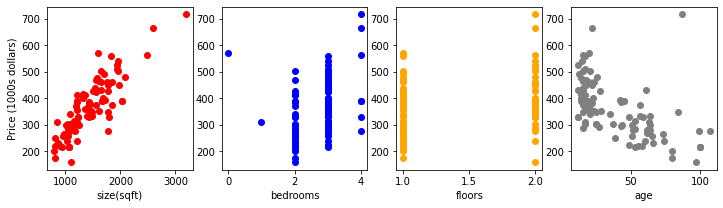

In [64]:
fig, ax = plt.subplots(1,4,figsize=(12,3))
ax[0].scatter(training_data['size(sqft)'],training_data['Price (1000s dollars)'],c='red')
ax[0].set_xlabel("size(sqft)")
ax[0].set_ylabel("Price (1000s dollars)")
ax[1].scatter(training_data['bedrooms'],training_data['Price (1000s dollars)'],c='blue')
ax[1].set_xlabel("bedrooms")
ax[2].scatter(training_data['floors'],training_data['Price (1000s dollars)'],c='orange')
ax[2].set_xlabel("floors")
ax[3].scatter(training_data['age'],training_data['Price (1000s dollars)'],c='gray')
ax[3].set_xlabel("age")
plt.show()

In [65]:
X_train = training_data.iloc[:,0:-1].to_numpy()
y_train = training_data.iloc[:,-1].to_numpy()

In [66]:
X_train[:5]

array([[1244.,    3.,    1.,   64.],
       [1947.,    3.,    2.,   17.],
       [1725.,    3.,    2.,   42.],
       [1959.,    3.,    2.,   15.],
       [1314.,    2.,    1.,   14.]])

In [67]:
y_train.shape

(99,)

In [68]:
y_train[:5]

array([300. , 509.8, 394. , 540. , 415. ])

In [69]:
# # data is stored in numpy array/matrix
# print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
# print(X_train)
# print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
# print(y_train)

### Parameter initalization

In [70]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


### Single prediction vector will be used with final w, b parameters and given feature to predict the value

In [71]:
def single_prediction_vector(x,w,b):
    """
    single predict using linear regression. 
    """
    p  = np.dot(x,w) + b
    return p


In [72]:
# get zero row, all columns and used the initialized value to predict the value for given vector. 
single_prediction_vector(X_train[0,:],w_init,b_init)

-416.06094562059184

### Compute Cost of the model ( MSE Error ) 

In [81]:
def compute_cost(X, y, w, b): 
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
      
    """
    
    
    m = X.shape[0]
    cost = 0
    
    for i in range(m):
        y_hat = np.dot(X[i],w ) + b
        y_actual = y[i]
        cost = cost + ( y_hat - y_actual ) ** 2
    cost = cost/(2*m)        
    return cost

In [82]:
total_cost = compute_cost(X_train, y_train, w_init, b_init)

In [83]:
total_cost

222244.79727732827

<a name="toc_15456_5"></a>
### 5 Gradient Descent With Multiple Variable



Gradient descent for multiple variables:

$$\begin{align*} 
\text{ repeat until convergence : } \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value

In [84]:
# calculate dj_dw , dj_db

def compute_gradient(X,y,w,b ):
    
    """
    Args: 
    X ( ndarray (m,n)) : Training dataset, with m samples, n features
    y ( ndarray (m,)) : traget values
    w ( ndarray (n,)) : weight parameters
    b ( scalar ) : traget values
    
    Returns:
    dj_dw | derivative of cost function w.r.t to w
    dj_db | derivative of cost function w.r.t to b
    
    """
    
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.
    
    for i in range(m):    
        y_hat = np.dot(X[i],w) + b 
        error = y_hat - y[i]
#         for j in range(n):                         
#             dj_dw[j] = dj_dw[j] + error * X[i, j]  
        dj_dw =  dj_dw + np.dot(error,X[i])
        dj_db = dj_db + error
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw,dj_db    

In [85]:
#Compute and display gradient 
tmp_dj_dw,tmp_dj_db = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -59.95155006594532
dj_dw at initial w,b: 
 [ 14355.222424   -101.694361      1.497197 -19293.913339]


<a name="toc_15456_5"></a>
### 5 Gradient Descent With Multiple Variables

In [86]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    """
    Perform gradient descent to learn w and b. updates w and b by taking num_iters gradient steps with learning rate alpha
    X (ndarray (m,n) : m no of training samples, n : no of features
    y (ndarray (m,) :  Target variable
    w_in : initialize weights parameter
    b_in : initialize intercept parameter
    cost_function 
    gradient_function, 
    alpha : learning rate
    num_iters : no of teration you want to perform before convergence. 
    
    return 
    iteration_cost (ndarray (num_iters,) : 
    w_final ( ndarray (n ,) : final weight parameter
    b_final (scalar ) : final intercept parameter
    """
    
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    j_history = list() 
    
    for i in range(num_iters):
        
        dj_dw , dj_db = gradient_function(X,y,w,b)
 
        # update the parameter
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # add itteration cost
        if i <100000:
            j_history.append(cost_function(X,y,w,b))
        
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {j_history[-1]:8.2f}")
            
    return w,b, j_history

In [90]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# print(initial_w)
# some gradient descent settings
iterations = 10000
alpha = 5.0e-7
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,compute_cost, compute_gradient,  alpha, iterations)
                                                   
                                                    
# print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
# m,_ = X_train.shape
# for i in range(m):
#     print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost  2161.10
Iteration 1000: Cost  1432.21
Iteration 2000: Cost  1372.78
Iteration 3000: Cost  1348.92
Iteration 4000: Cost  1339.31
Iteration 5000: Cost  1335.43
Iteration 6000: Cost  1333.83
Iteration 7000: Cost  1333.16
Iteration 8000: Cost  1332.86
Iteration 9000: Cost  1332.70


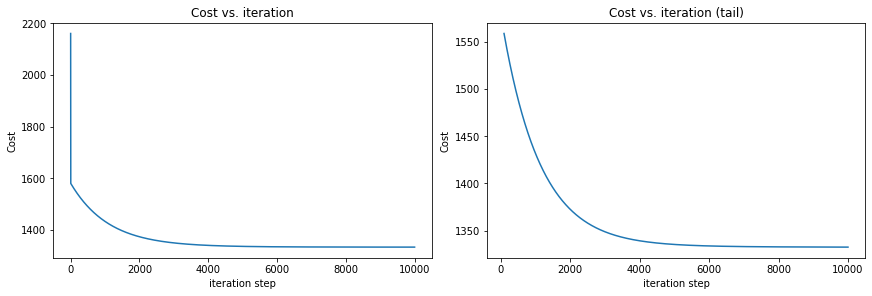

In [91]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

Iteration    0: Cost 95588.40
Iteration  100: Cost 815254383580017280.00
Iteration  200: Cost 7070012321553775537900385992704.00
Iteration  300: Cost 61312242207669664407873959867534567693877248.00
Iteration  400: Cost 531709263514530386590751847840432182616786920404380811264.00
Iteration  500: Cost 4611065110774830821795768962906606559415705584016370013655608930074624.00
Iteration  600: Cost 39987871031747630765384698130256661694799691934215165436316955138770656165980274688.00
Iteration  700: Cost 346781012897698293840882223373675566642546741303183471239223378411522020065466946106328287805440.00
Iteration  800: Cost 3007338670540279962591508959037346697146539747733665164400934620308085469290714334853258716443353199564292096.00
Iteration  900: Cost 26080106877117953551699150325263955063322677368075434295124624898938080110524710586247811944434390696226938332304327573504.00
Next Alpha 



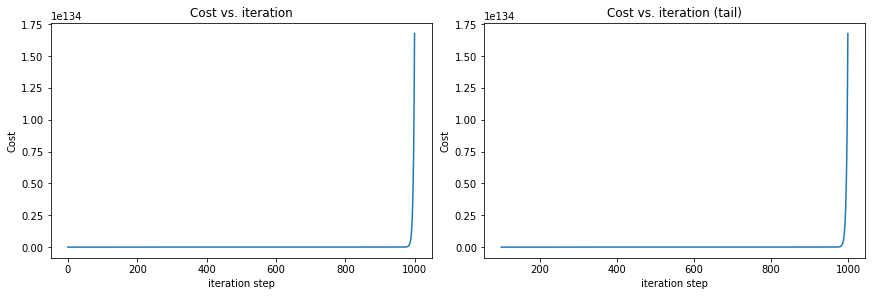

Iteration    0: Cost 66461.58
Iteration  100: Cost  1586.90
Iteration  200: Cost  1510.91
Iteration  300: Cost  1483.90
Iteration  400: Cost  1461.02
Iteration  500: Cost  1441.60
Iteration  600: Cost  1425.13
Iteration  700: Cost  1411.16
Iteration  800: Cost  1399.30
Iteration  900: Cost  1389.25
Next Alpha 



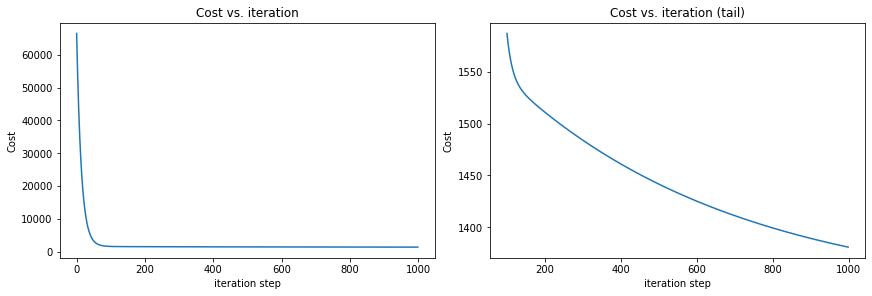

Iteration    0: Cost  2161.10
Iteration  100: Cost  1558.75
Iteration  200: Cost  1539.04
Iteration  300: Cost  1521.05
Iteration  400: Cost  1504.63
Iteration  500: Cost  1489.65
Iteration  600: Cost  1475.97
Iteration  700: Cost  1463.49
Iteration  800: Cost  1452.10
Iteration  900: Cost  1441.70
Next Alpha 



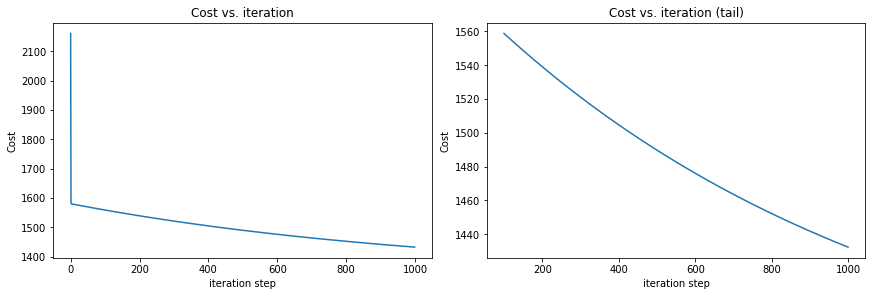

Iteration    0: Cost 44231.27
Iteration  100: Cost  1576.04
Iteration  200: Cost  1571.64
Iteration  300: Cost  1567.32
Iteration  400: Cost  1563.08
Iteration  500: Cost  1558.91
Iteration  600: Cost  1554.83
Iteration  700: Cost  1550.81
Iteration  800: Cost  1546.87
Iteration  900: Cost  1543.00
Next Alpha 



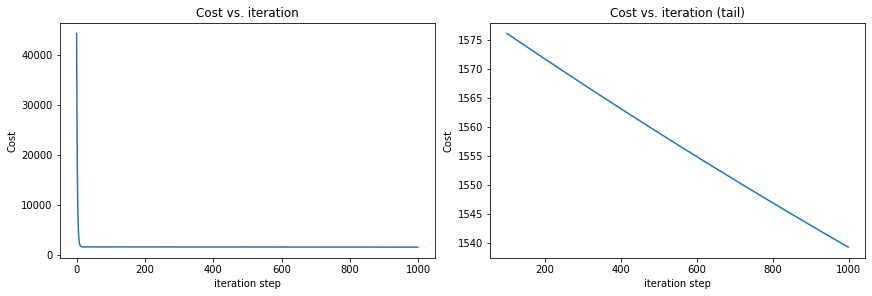

Iteration    0: Cost 71338.76
Iteration  100: Cost 68359.07
Iteration  200: Cost 65506.65
Iteration  300: Cost 62776.07
Iteration  400: Cost 60162.12
Iteration  500: Cost 57659.83
Iteration  600: Cost 55264.42
Iteration  700: Cost 52971.33
Iteration  800: Cost 50776.19
Iteration  900: Cost 48674.82
Next Alpha 



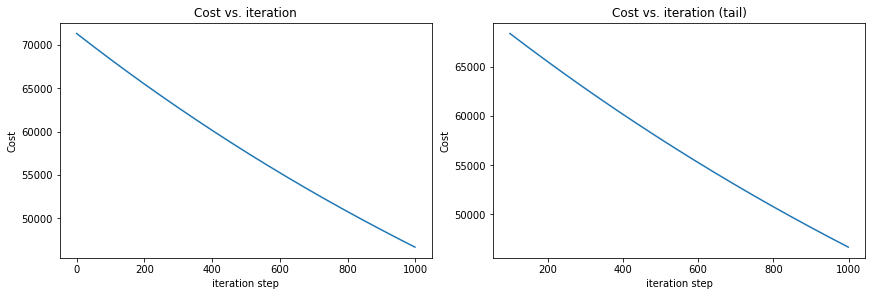

In [106]:
# _, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 9.9e-7)
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# print(initial_w)
# some gradient descent settings
iterations = 1000
# alpha = 
# alpha = 
# alpha = 
# alpha = 
for alpha in [9.9e-7,9e-7,5.0e-7,1e-7,1e-10]:
    w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,compute_cost, compute_gradient,  alpha, iterations)
    print("Next Alpha","\n")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
    ax1.plot(J_hist)
    ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
    ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
    ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
    ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
    plt.show()

                                                   
                                                    
# print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
# m,_ = X_train.shape
# for i in range(m):
#     print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")